In [1]:
#LOADING MAIN LIBRARIES
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from tqdm import tqdm

import os

In [2]:
#SETTING UP MAIN DIRECTORIES
mainDirectory = "/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/"

In [3]:
#DIRECTORY FUNCTIONS
def ListFiles(directory, n=10):
    files = os.listdir(directory)
    print("Listing first", n, "files:\n", files[:n], "\n")
    return files

In [4]:
#LOADING CLASSES
# --- Add your Functions folder to sys.path ---
import sys
path = mainDirectory + '/Functions_2.0/Classes'
sys.path.append(path)

# --- Import all your function modules ---
import importlib
modules = [
    "Classes_MapPlotting"
]

for mod in modules:
    globals()[mod] = importlib.import_module(mod)        # import module itself
    globals().update(vars(globals()[mod]))              # import all functions into global namespace

In [5]:
################################################################################

In [6]:
#DATA DESCRIPTIONS

### Data Type
# MicroPulse Differential Absorption Lidar (MPD)

### DOI (Permanent Link)
# https://doi.org/10.26023/50Z5-ZHXE-7B0D

### Summary
# MicroPulse Differential Absorption Lidar (MPD) data 
# in NetCDF format which were collected during the 
# Prediction of Rainfall Extremes Campaign In the Pacific (PRECIP). 
# Three MPDs were deployed to Taiwan for this field project.

### Temporal Coverage
# Begin datetime 2022-05-28 00:00:00
# End datetime 2022-08-22 23:59:59

### Spatial Coverage
# Maximum (North) Latitude: 24.97, Minimum (South) Latitude: 24.76
# Minimum (West) Longitude: 121.01, Maximum (East) Longitude: 121.76

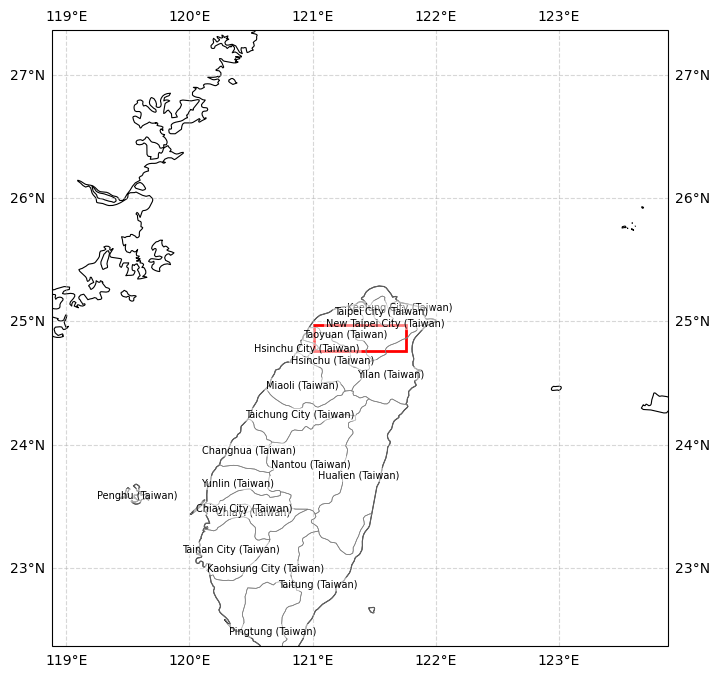

In [7]:
mapPlotting = MapPlotting(
    sw_corner=(24.76, 121.01),  # (lat_min, lon_min)
    ne_corner=(24.97, 121.76),  # (lat_max, lon_max)
    delta=2.5,
    fontsize=7
)
mapPlotting.PlotBoundingBox()

In [8]:
################################################################################

In [9]:
#SET UP DIRECTORIES
Campaign="PRECIP"

#Code Directory
Code_Directory="/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/Observation_Data"
Code_Directory=os.path.join(Code_Directory,Campaign)
print("Code Directory Set as:", Code_Directory, '\n')

#Data Directory
DataType="PRECIP_NCAR_MPD_Data"
Observation_Data_Directory = "/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data"
Data_Directory1 = os.path.join(Observation_Data_Directory,Campaign,DataType,"unzip","MPD_02")
print("Data Directory Set as:", Data_Directory1, '\n')
FileList1 = ListFiles(Data_Directory1)

Data_Directory2 = os.path.join(Observation_Data_Directory,Campaign,DataType,"unzip","MPD_03")
print("Data Directory Set as:", Data_Directory2, '\n')
FileList2 = ListFiles(Data_Directory2)

Data_Directory3 = os.path.join(Observation_Data_Directory,Campaign,DataType,"unzip","MPD_04")
print("Data Directory Set as:", Data_Directory3, '\n')
FileList3 = ListFiles(Data_Directory3)

#Output Directory
Output_Directory="/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data"
Output_Directory=os.path.join(Output_Directory,Campaign,DataType)

Code Directory Set as: /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/Observation_Data/PRECIP 

Data Directory Set as: /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data/PRECIP/PRECIP_NCAR_MPD_Data/unzip/MPD_02 

Listing first 10 files:
 ['mpd02.20220626.Python.nc', 'mpd02.20220703.Python.nc', 'mpd02.20220727.Python.nc', 'mpd02.20220729.Python.nc', 'mpd02.20220802.Python.nc', 'mpd02.20220618.Python.nc', 'mpd02.20220530.Python.nc', 'mpd02.20220719.Python.nc', 'mpd02.20220614.Python.nc', 'mpd02.20220627.Python.nc'] 

Data Directory Set as: /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data/PRECIP/PRECIP_NCAR_MPD_Data/unzip/MPD_03 

Listing first 10 files:
 ['mpd03.20220710.Python.nc', 'mpd03.20220812.Python.nc', 'mpd03.20220613.Python.nc', 'mpd03.20220610.Python.nc', 'mpd03.20220802.Python.nc', 'mpd03.20220529.Python.nc', 'mpd03.20220616.Python.nc', 'mpd03.20220528.Python.nc', 'mpd03.20220721.P

In [10]:
#READING DATA FUNCTIONS
###################################

In [11]:
def FindFile(FileList,target):
    index = next((i for i, f in enumerate(FileList) if target in f), -1)
    return index
    
def GetData(Data_Directory,FileList,index):
    DataFile = os.path.join(Data_Directory,FileList[index])
    DataNC = xr.open_dataset(DataFile)
    return DataNC

In [200]:
#PLOTTING FUNCTIONS
###################################

In [13]:
#GETTING COLORMAPS

# The Python ARM Radar Toolkit - Py-ART
# git clone https://github.com/ProjectPythia/radar-cookbook.git
# pip install arm_pyart
import pyart

import inspect
print(inspect.getsource(pyart.config.get_field_colormap))
print(pyart.config._DEFAULT_FIELD_COLORMAP.keys())


cmap_reflectivity = pyart.config.get_field_colormap('reflectivity')
# cmap_dBZ = pyart.config.get_field_colormap('dBZ') #same as reflectivity
# cmap_dbz = pyart.config.get_field_colormap('dbz') #same as reflectivity
# cmap_DBZ = pyart.config.get_field_colormap('DBZ') #same as reflectivity
cmap_viridis = plt.cm.viridis
cmap_inferno = plt.cm.inferno
# import matplotlib.cm as cm
# cmap = cm.get_cmap(cmap_reflectivity)
# cmap


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119

def get_field_colormap(field):
    """
    Return the colormap name from the configuration file for a field name.
    """
    if field in _DEFAULT_FIELD_COLORMAP:
        return _DEFAULT_FIELD_COLORMAP[field]
    else:
        import matplotlib

        # Use the default matplotlib colormap
        return matplotlib.colormaps.get_cmap("Spectral_r").name

dict_keys(['reflectivity', 'corrected_reflectivity', 'total_power', 'signal_to_noise_ratio', 'velocity', 'corrected_velocity', 'simulated_velocity', 'eastward_wind_component', 'northward_wind_compo

In [26]:
import numpy as np

def QuickPlot_tz(ax, DataNC, varName, cmap='Viridis', rangeSlice=None, data_min=None, mask_zeros=False):
    da = DataNC[varName]

    if rangeSlice is not None:
        # If user gave a slice of physical values
        if isinstance(rangeSlice, slice):
            coords = DataNC['range'].values

            # Handle start
            if rangeSlice.start is not None:
                start_idx = np.abs(coords - rangeSlice.start).argmin()
            else:
                start_idx = None

            # Handle stop
            if rangeSlice.stop is not None:
                stop_idx = np.abs(coords - rangeSlice.stop).argmin()
            else:
                stop_idx = None

            # Construct index slice
            da = da.isel(range=slice(start_idx, stop_idx))
        else:
            # If scalar, just pick nearest value
            da = da.sel(range=rangeSlice, method="nearest")

    if data_min!=None:
        da = da.where(abs(da) >= data_min)
    if mask_zeros==True:
        da = da.where(da != 0)
    da.T.plot(ax=ax, add_colorbar=True, cmap=cmap)
    ax.set_title(varName)
    # ax.set_ylim(bottom=0)

def PlotData(DataNC, vars_to_plot, data_min=None, mask_zeros=False, Max_ZLevel=15000, OutputDirectory=None, OutputName=None):
    fig = plt.figure(figsize=(12, 8), constrained_layout=True)
    gs = gridspec.GridSpec(2, 2, figure=fig)
    
    # --- Create subplots using GridSpec ---
    axes = [fig.add_subplot(gs[i, j]) for i in range(2) for j in range(2)]
    
    # --- Fill with plots ---
    for ax, (var, cmap) in zip(axes, vars_to_plot):
        QuickPlot_tz(ax, DataNC, var, cmap=cmap, data_min=data_min, rangeSlice=slice(0, Max_ZLevel), mask_zeros=mask_zeros)

    if (OutputDirectory!=None) and (OutputName!=None):
        #Saving
        filepath = os.path.join(OutputDirectory, OutputName)
        os.makedirs(os.path.dirname(filepath), exist_ok=True)
        plt.savefig(filepath, dpi=150)
        print(f"Saving plot in {filepath}")
    
        #Supressing Figure
        plt.close(fig) 

In [27]:
#PLOTTING
###################################

In [28]:
# --- Variables to plot ---
vars_to_plot = [
    ("Relative_Backscatter", cmap_reflectivity),
    ("Absolute_Humidity",    cmap_viridis),
    ("WVOffline",            cmap_reflectivity),
    ("WVOnline",             cmap_inferno),
]

data_sources = [
    (Data_Directory1, FileList1),
    (Data_Directory2, FileList2),
    (Data_Directory3, FileList3),
    ]

In [29]:
#MOIST CASES
# 05/24 - 05/28
# 06/07 - 06/08
# 06/11 - 06/12
# 08/11 (but strong mid-level drying)

target_list = [
    "20220524","20220525","20220526","20220527","20220528",   # 05/24 - 05/28
    "20220607","20220608",                                   # 06/07 - 06/08
    "20220611","20220612",                                   # 06/11 - 06/12
    "20220811"                                               # 08/11
]

In [30]:
for data_dir, file_list in data_sources:
    print(f"\n Processing directory: {data_dir}")
    baseName=os.path.basename(data_dir)
    for target in target_list:
        index = FindFile(FileList=file_list, target=target)
        if index == -1:
            print(f"{target} not found in {data_dir}")
            continue
        
        DataNC = GetData(Data_Directory=data_dir, FileList=file_list, index=index)
        PlotData(DataNC, vars_to_plot, data_min=None, mask_zeros=True, Max_ZLevel=15000, OutputDirectory=Output_Directory+"/Moist/"+baseName, OutputName=target)


 Processing directory: /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data/PRECIP/PRECIP_NCAR_MPD_Data/unzip/MPD_02
20220524 not found in /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data/PRECIP/PRECIP_NCAR_MPD_Data/unzip/MPD_02
20220525 not found in /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data/PRECIP/PRECIP_NCAR_MPD_Data/unzip/MPD_02
20220526 not found in /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data/PRECIP/PRECIP_NCAR_MPD_Data/unzip/MPD_02
20220527 not found in /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data/PRECIP/PRECIP_NCAR_MPD_Data/unzip/MPD_02
Saving plot in /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data/PRECIP/PRECIP_NCAR_MPD_Data/Moist/MPD_02/20220528
Saving plot in /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data/PRECIP

In [31]:
# DRY CASES
# 05/28 - 05/29
# 06/05
# 07/05 - 07/07
# 07/15 - 07/18
# 07/21
# 07/23 - 07/24

target_list = [
    "20220528","20220529",      # 05/28 - 05/29
    "20220605",                 # 06/05
    "20220705","20220706","20220707",   # 07/05 - 07/07
    "20220715","20220716","20220717","20220718",  # 07/15 - 07/18
    "20220721",                 # 07/21
    "20220723","20220724"       # 07/23 - 07/24
]

In [32]:
for data_dir, file_list in data_sources:
    print(f"\n Processing directory: {data_dir}")
    baseName=os.path.basename(data_dir)
    for target in target_list:
        index = FindFile(FileList=file_list, target=target)
        if index == -1:
            print(f"{target} not found in {data_dir}")
            continue
        
        DataNC = GetData(Data_Directory=data_dir, FileList=file_list, index=index)
        PlotData(DataNC, vars_to_plot, data_min=None, mask_zeros=True, Max_ZLevel=15000, OutputDirectory=Output_Directory+"/Dry/"+baseName, OutputName=target)


 Processing directory: /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data/PRECIP/PRECIP_NCAR_MPD_Data/unzip/MPD_02
Saving plot in /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data/PRECIP/PRECIP_NCAR_MPD_Data/Dry/MPD_02/20220528
Saving plot in /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data/PRECIP/PRECIP_NCAR_MPD_Data/Dry/MPD_02/20220529
Saving plot in /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data/PRECIP/PRECIP_NCAR_MPD_Data/Dry/MPD_02/20220605
Saving plot in /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data/PRECIP/PRECIP_NCAR_MPD_Data/Dry/MPD_02/20220705
Saving plot in /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data/PRECIP/PRECIP_NCAR_MPD_Data/Dry/MPD_02/20220706
Saving plot in /glade/u/home/aroseman/Projects/Regional-MPA